# Fase 3: Il Motore Scacchistico (Minimax) e L'Arena

In questo notebook i nostri due modelli passano dalla teoria alla pratica. Smetteranno di valutare solo la posizione attuale e inizieranno a "pensare" al futuro esplorando le varianti.

## L'Algoritmo: Minimax con Potatura Alpha-Beta
Implementeremo un albero di ricerca a **profondità 4** (che calcola: Mossa mia -> Risposta sua -> Mossa mia -> Risposta sua). 
* Il **Bianco** cercherà di *Massimizzare* il punteggio (+1).
* Il **Nero** cercherà di *Minimizzare* il punteggio (-1).

La **Potatura Alpha-Beta** taglierà matematicamente i rami dell'albero che portano a esiti chiaramente svantaggiosi, risparmiando un enorme costo computazionale.

## Il Test Visivo e i Puzzle
Creeremo un'interfaccia grafica per vedere la scacchiera e la mossa scelta (indicata da una freccia). Successivamente, useremo posizioni tattiche note (Matti in 1 o 2) come "Giudice" per capire quale modello trova la mossa corretta.

In [1]:
# =================================================================
# CELLA 2: LIBRERIE E FUNZIONI DI TRADUZIONE FEN (Notebook 4)
# =================================================================
import torch
import torch.nn as nn
import numpy as np
import chess
import chess.svg
from IPython.display import display, SVG

PIECE_MAP = {'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,
             'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11}

def fen_to_768_fast(fen):
    vector = np.zeros(768, dtype=np.float32)
    board_part = fen.split(' ')[0]
    rank, file = 7, 0
    for char in board_part:
        if char == '/':
            rank -= 1
            file = 0
        elif char.isdigit():
            file += int(char)
        else:
            vector[(PIECE_MAP[char] * 64) + (rank * 8 + file)] = 1.0
            file += 1
    return vector

def extract_13_features(fen):
    board = chess.Board(fen)
    features = np.zeros(13, dtype=np.float32) 
    valori = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9}
    mat_W = mat_B = center_W = center_B = dev_W = dev_B = harmony_W = harmony_B = 0
    case_centrali = [chess.E4, chess.D4, chess.E5, chess.D5]
    
    for sq in chess.SQUARES:
        piece = board.piece_at(sq)
        if not piece: continue
        color = piece.color
        ptype = piece.piece_type
        rank = chess.square_rank(sq)
        
        if ptype != chess.KING:
            if color == chess.WHITE: mat_W += valori[ptype]
            else: mat_B += valori[ptype]
        for c_sq in case_centrali:
            if board.is_attacked_by(color, c_sq):
                if color == chess.WHITE: center_W += 1
                else: center_B += 1
        if ptype in [chess.KNIGHT, chess.BISHOP]:
            if color == chess.WHITE and rank == 0: dev_W -= 1
            if color == chess.BLACK and rank == 7: dev_B -= 1
        if len(board.attackers(color, sq)) > 0:
            if color == chess.WHITE: harmony_W += 1
            else: harmony_B += 1

    features[0] = mat_W - mat_B
    features[1] = (0.5 if len(board.pieces(chess.BISHOP, chess.WHITE)) >= 2 else 0) - (0.5 if len(board.pieces(chess.BISHOP, chess.BLACK)) >= 2 else 0)
    features[2] = ((len(board.pieces(chess.KNIGHT, chess.WHITE)) + len(board.pieces(chess.BISHOP, chess.WHITE))) - (len(board.pieces(chess.ROOK, chess.WHITE)) + len(board.pieces(chess.QUEEN, chess.WHITE)))) - ((len(board.pieces(chess.KNIGHT, chess.BLACK)) + len(board.pieces(chess.BISHOP, chess.BLACK))) - (len(board.pieces(chess.ROOK, chess.BLACK)) + len(board.pieces(chess.QUEEN, chess.BLACK))))
    
    board.turn = chess.WHITE; mob_W = board.legal_moves.count()
    board.turn = chess.BLACK; mob_B = board.legal_moves.count()
    features[3] = mob_W - mob_B
    features[4] = center_W - center_B
    features[5] = dev_W - dev_B
    features[6] = 0.0 
    
    f_W = [chess.square_file(sq) for sq in board.pieces(chess.PAWN, chess.WHITE)]
    f_B = [chess.square_file(sq) for sq in board.pieces(chess.PAWN, chess.BLACK)]
    features[7] = -((len(f_W) - len(set(f_W))) - (len(f_B) - len(set(f_B))))
    features[8] = 0.0 
    
    king_W = board.king(chess.WHITE)
    king_B = board.king(chess.BLACK)
    features[9] = (-sum(len(board.attackers(chess.BLACK, adj)) for adj in chess.SQUARES if king_W and chess.square_distance(king_W, adj) <= 1)) - (-sum(len(board.attackers(chess.WHITE, adj)) for adj in chess.SQUARES if king_B and chess.square_distance(king_B, adj) <= 1))
    features[10] = harmony_W - harmony_B
    
    conn_W = conn_B = 0
    rooks_W = list(board.pieces(chess.ROOK, chess.WHITE))
    if len(rooks_W) >= 2 and set(board.attackers(chess.WHITE, rooks_W[0])) & set(rooks_W): conn_W = 1
    rooks_B = list(board.pieces(chess.ROOK, chess.BLACK))
    if len(rooks_B) >= 2 and set(board.attackers(chess.BLACK, rooks_B[0])) & set(rooks_B): conn_B = 1
    features[11] = conn_W - conn_B

    original_turn = board.turn 
    board.turn = chess.WHITE
    features[12] = sum(1 for m in board.legal_moves if board.gives_check(m))
    board.turn = chess.BLACK
    features[12] -= sum(1 for m in board.legal_moves if board.gives_check(m))
    board.turn = original_turn 

    return features

print("✅ Funzioni di estrazione aggiornate (13 Feature).")

✅ Funzioni di estrazione aggiornate (13 Feature).


In [2]:
# =================================================================
# CELLA 3: CARICAMENTO DEI MODELLI E VALUTATORI (Notebook 4)
# =================================================================
class MotoreScacchiNN(nn.Module):
    def __init__(self):
        super(MotoreScacchiNN, self).__init__()
        self.strato_1 = nn.Linear(768, 256)
        self.attivazione_1 = nn.ReLU()
        self.strato_2 = nn.Linear(256, 32)
        self.attivazione_2 = nn.ReLU()
        self.strato_output = nn.Linear(32, 1)
    def forward(self, x):
        return self.strato_output(self.attivazione_2(self.strato_2(self.attivazione_1(self.strato_1(x)))))

class ModelloEuristico(nn.Module):
    def __init__(self):
        super(ModelloEuristico, self).__init__()
        self.lineare = nn.Linear(13, 1) # AGGIORNATO A 13
    def forward(self, x):
        return self.lineare(x)

modello_1 = MotoreScacchiNN()
modello_1.load_state_dict(torch.load('pesi_modello_1_deep_learning.pth', weights_only=True))
modello_1.eval()

modello_2 = ModelloEuristico()
modello_2.load_state_dict(torch.load('pesi_modello_2_quasi_newton.pth', weights_only=True))
modello_2.eval()

def valuta_modello_1(board):
    if board.is_checkmate(): return -1.0 if board.turn else 1.0 
    v = torch.tensor(fen_to_768_fast(board.fen()), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad(): return modello_1(v).item()

def valuta_modello_2(board):
    if board.is_checkmate(): return -1.0 if board.turn else 1.0
    # AGGIORNATO ALLA CHIAMATA 13 FEATURE
    v = torch.tensor(extract_13_features(board.fen()), dtype=torch.float32).unsqueeze(0) 
    with torch.no_grad(): return modello_2(v).item()

print("✅ Modelli caricati con successo!")

✅ Modelli caricati con successo!


In [3]:
# =================================================================
# CARICAMENTO MODELLO 1 ESPANSO (512 Neuroni)
# (Esegui questa cella per usare il modello potenziato nei test)
# =================================================================
import torch
import torch.nn as nn
import numpy as np
import chess

# 1. Stessa identica struttura usata per l'addestramento
class MotoreScacchiNN_512(nn.Module):
    def __init__(self):
        super(MotoreScacchiNN_512, self).__init__()
        self.strato_1 = nn.Linear(768, 512)
        self.attivazione_1 = nn.ReLU()
        self.strato_2 = nn.Linear(512, 64)
        self.attivazione_2 = nn.ReLU()
        self.strato_output = nn.Linear(64, 1)

    def forward(self, x):
        x = self.attivazione_1(self.strato_1(x))
        x = self.attivazione_2(self.strato_2(x))
        return self.strato_output(x)

# 2. Caricamento del nuovo file pesi
modello_1 = MotoreScacchiNN_512()
# Aggiungi map_location=torch.device('cpu') per sicurezza se non usi GPU nel test
modello_1.load_state_dict(torch.load('modello_1_512_pesi.pth', map_location=torch.device('cpu')))
modello_1.eval()

# 3. Ridefinizione della funzione di valutazione
# Sovrascrive quella vecchia in memoria in modo trasparente per il resto del codice
def valuta_modello_1(board):
    matrice = np.zeros(768, dtype=np.float32)
    for casella in chess.SQUARES:
        pezzo = board.piece_at(casella)
        if pezzo:
            offset = 0 if pezzo.color == chess.WHITE else 384
            indice = offset + (pezzo.piece_type - 1) * 64 + casella
            matrice[indice] = 1.0
            
    tensore = torch.tensor(matrice).unsqueeze(0)
    with torch.no_grad():
        voto = modello_1(tensore).item()
    
    # Regola il segno in base a chi muove
    return voto if board.turn == chess.WHITE else -voto

class ModelloEuristico(nn.Module):
    def __init__(self):
        super(ModelloEuristico, self).__init__()
        self.lineare = nn.Linear(13, 1) # AGGIORNATO A 13
    def forward(self, x):
        return self.lineare(x)

modello_1 = MotoreScacchiNN_512()
modello_1.load_state_dict(torch.load('modello_1_512_pesi.pth', weights_only=True))
modello_1.eval()

modello_2 = ModelloEuristico()
modello_2.load_state_dict(torch.load('pesi_modello_2_quasi_newton.pth', weights_only=True))
modello_2.eval()

def valuta_modello_1(board):
    if board.is_checkmate(): return -1.0 if board.turn else 1.0 
    v = torch.tensor(fen_to_768_fast(board.fen()), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad(): return modello_1(v).item()

def valuta_modello_2(board):
    if board.is_checkmate(): return -1.0 if board.turn else 1.0
    # AGGIORNATO ALLA CHIAMATA 13 FEATURE
    v = torch.tensor(extract_13_features(board.fen()), dtype=torch.float32).unsqueeze(0) 
    with torch.no_grad(): return modello_2(v).item()

print("✅ Modelli caricati con successo!")
print("Le Celle del Benchmark e del Match Uomo vs AI useranno ora questa versione.")

✅ Modelli caricati con successo!
Le Celle del Benchmark e del Match Uomo vs AI useranno ora questa versione.


In [4]:
# =================================================================
# CELLA 4: MOTORE DECISIONALE E CONFIGURAZIONE DI RICERCA GLOBALE
# =================================================================
import chess
import chess.svg
from IPython.display import display, SVG, clear_output

# -----------------------------------------------------------------
# PARAMETRI GLOBALI DI RICERCA
# Modificare esclusivamente queste due variabili per i test
# -----------------------------------------------------------------
PROFONDITA_RICERCA = 4  # Livelli di profondità dell'albero Minimax
LARGHEZZA_BEAM     = 5  # Numero di mosse valutate per ramo (Beam Search)
# -----------------------------------------------------------------

def disegna_scacchiera(board, mossa_evidenziata=None, frecce_multiple=None, dimensione=400):
    """
    Renderizza la scacchiera in formato SVG.
    Supporta l'evidenziazione dell'ultima mossa o frecce multiple per analisi.
    """
    frecce = frecce_multiple if frecce_multiple else []
    if mossa_evidenziata:
        frecce.append(chess.svg.Arrow(mossa_evidenziata.from_square, mossa_evidenziata.to_square, color="red"))
    display(SVG(chess.svg.board(board, arrows=frecce, size=dimensione)))

def valutazione_minimax(board, depth, alpha, beta, is_maximizing, valuta_func):
    """Implementazione standard dell'algoritmo Minimax con potatura Alpha-Beta."""
    if depth == 0 or board.is_game_over():
        return valuta_func(board)
    
    if is_maximizing:
        max_eval = -float('inf')
        for move in board.legal_moves:
            board.push(move)
            eval_corr = valutazione_minimax(board, depth - 1, alpha, beta, False, valuta_func)
            board.pop()
            max_eval = max(max_eval, eval_corr)
            alpha = max(alpha, eval_corr)
            if beta <= alpha: break
        return max_eval
    else:
        min_eval = float('inf')
        for move in board.legal_moves:
            board.push(move)
            eval_corr = valutazione_minimax(board, depth - 1, alpha, beta, True, valuta_func)
            board.pop()
            min_eval = min(min_eval, eval_corr)
            beta = min(beta, eval_corr)
            if beta <= alpha: break
        return min_eval

def ricerca_mossa_migliore(board, valuta_func):
    """
    Inizializza la ricerca della mossa ottimale.
    Combina Beam Search (filtro iniziale) e Minimax.
    Si affida ai parametri globali PROFONDITA_RICERCA e LARGHEZZA_BEAM.
    """
    mosse_valutate = []
    is_maximizing = board.turn == chess.WHITE
    
    # Valutazione euristica statica di base (Profondità 0)
    for move in board.legal_moves:
        board.push(move)
        score = valuta_func(board)
        board.pop()
        mosse_valutate.append((score, move))
    
    # Ordinamento e selezione del fascio (Beam)
    mosse_valutate.sort(key=lambda x: x[0], reverse=is_maximizing)
    beam = mosse_valutate[:LARGHEZZA_BEAM]
    
    # Ricerca profonda sulle mosse selezionate
    mossa_ottimale = beam[0][1]
    
    if is_maximizing:
        best_score = -float('inf')
        for _, move in beam:
            board.push(move)
            score = valutazione_minimax(board, PROFONDITA_RICERCA - 1, -float('inf'), float('inf'), False, valuta_func)
            board.pop()
            if score > best_score:
                best_score = score
                mossa_ottimale = move
    else:
        best_score = float('inf')
        for _, move in beam:
            board.push(move)
            score = valutazione_minimax(board, PROFONDITA_RICERCA - 1, -float('inf'), float('inf'), True, valuta_func)
            board.pop()
            if score < best_score:
                best_score = score
                mossa_ottimale = move
                
    return mossa_ottimale

print(f"[SISTEMA] Motore di ricerca inizializzato.")
print(f"[CONFIG] Profondità: {PROFONDITA_RICERCA} | Beam: {LARGHEZZA_BEAM}")

[SISTEMA] Motore di ricerca inizializzato.
[CONFIG] Profondità: 4 | Beam: 5


--- AVVIO BENCHMARK [Profondità: 4, Beam: 5] ---
Legenda Frecce -> BLU: Modello 1 (DL) | VERDE: Modello 2 (13 Feat)

Puzzle 1: Matto in 1 (Barbiere)
Modello 1: h5f7 [PASS] (3.74s)
Modello 2: h5f7 [PASS] (8.66s)


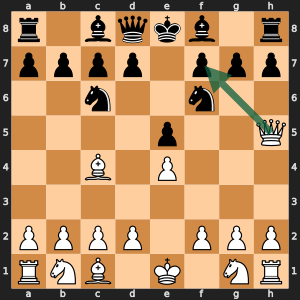

--------------------------------------------------
Puzzle 2: Guadagno di materiale (Forchetta)
Modello 1: d5e6 [FAIL] (26.72s)
Modello 2: c3d1 [FAIL] (77.11s)


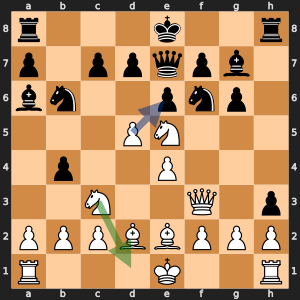

--------------------------------------------------
Puzzle 3: Matto in 1 (Torre in traversa)
Modello 1: e1e8 [PASS] (1.92s)
Modello 2: e1e8 [PASS] (2.98s)


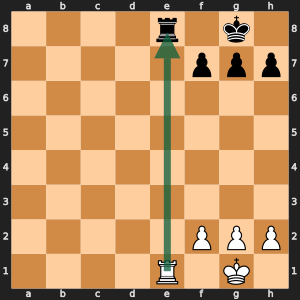

--------------------------------------------------
Puzzle 4: Inchiodatura del Cavallo
Modello 1: g1h3 [FAIL] (14.31s)
Modello 2: c3b1 [FAIL] (10.84s)


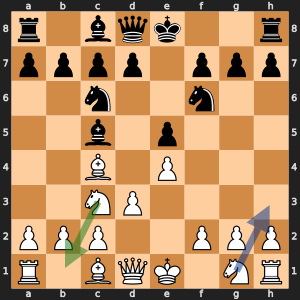

--------------------------------------------------
Puzzle 5: Finale di Re (Avvicinamento tattico)
Modello 1: d3c2 [FAIL] (0.00s)
Modello 2: d3e2 [FAIL] (0.01s)


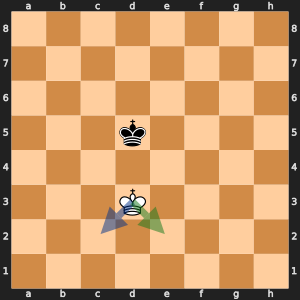

--------------------------------------------------
RISULTATI: Modello 1 [2/5] - Modello 2 [2/5]


In [5]:
# =================================================================
# CELLA 5: BENCHMARK TATTICO (Modello 1 vs Modello 2)
# =================================================================
import time
import chess
import chess.svg

puzzles = [
    ("r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4", "h5f7", "Matto in 1 (Barbiere)"),
    ("r3k2r/p1ppqpb1/bn2pnp1/3PN3/1p2P3/2N2Q1p/PPPBBPPP/R3K2R w KQkq - 0 1", "e5d7", "Guadagno di materiale (Forchetta)"),
    ("4r1k1/5ppp/8/8/8/8/5PPP/4R1K1 w - - 0 1", "e1e8", "Matto in 1 (Torre in traversa)"),
    ("r1bqk2r/pppp1ppp/2n2n2/2b1p3/2B1P3/2NP4/PPP2PPP/R1BQK1NR w KQkq - 1 5", "c1g5", "Inchiodatura del Cavallo"),
    ("8/8/8/3k4/8/3K4/8/8 w - - 0 1", "d3e3", "Finale di Re (Avvicinamento tattico)")
]

punteggio_m1, punteggio_m2 = 0, 0
print(f"--- AVVIO BENCHMARK [Profondità: {PROFONDITA_RICERCA}, Beam: {LARGHEZZA_BEAM}] ---")
print("Legenda Frecce -> BLU: Modello 1 (DL) | VERDE: Modello 2 (13 Feat)\n")

for i, (fen, mossa_target, desc) in enumerate(puzzles):
    board = chess.Board(fen)
    
    t_start = time.time()
    mossa_m1 = ricerca_mossa_migliore(board, valuta_modello_1)
    t_m1 = time.time() - t_start
    
    t_start = time.time()
    mossa_m2 = ricerca_mossa_migliore(board, valuta_modello_2)
    t_m2 = time.time() - t_start
    
    if str(mossa_m1) == mossa_target: punteggio_m1 += 1
    if str(mossa_m2) == mossa_target: punteggio_m2 += 1
        
    frecce_confronto = [
        chess.svg.Arrow(mossa_m1.from_square, mossa_m1.to_square, color="blue"),
        chess.svg.Arrow(mossa_m2.from_square, mossa_m2.to_square, color="green")
    ]
    
    print(f"Puzzle {i+1}: {desc}")
    print(f"Modello 1: {mossa_m1} [{'PASS' if str(mossa_m1) == mossa_target else 'FAIL'}] ({t_m1:.2f}s)")
    print(f"Modello 2: {mossa_m2} [{'PASS' if str(mossa_m2) == mossa_target else 'FAIL'}] ({t_m2:.2f}s)")
    
    # QUI LA CORREZIONE: frecce_multiple al posto di frecce_extra
    disegna_scacchiera(board, frecce_multiple=frecce_confronto, dimensione=300)
    print("-" * 50)

print(f"RISULTATI: Modello 1 [{punteggio_m1}/{len(puzzles)}] - Modello 2 [{punteggio_m2}/{len(puzzles)}]")

In [6]:
# =================================================================
# CELLA 6: MATCH AUTONOMO TRA MODELLI
# =================================================================
LIMITE_MOSSE = 50
board_match = chess.Board()

print(f"--- INIZIO MATCH: BIANCO (Modello 1) vs NERO (Modello 2) ---")
print(f"Parametri in uso: Profondità {PROFONDITA_RICERCA}, Beam {LARGHEZZA_BEAM}\n")

for mossa_idx in range(1, LIMITE_MOSSE + 1):
    if board_match.is_game_over():
        break
        
    valutatore_corrente = valuta_modello_1 if board_match.turn == chess.WHITE else valuta_modello_2
    mossa = ricerca_mossa_migliore(board_match, valutatore_corrente)
    board_match.push(mossa)
    
    print(f"{mossa_idx}.{mossa}", end="  ")
    if mossa_idx % 10 == 0: print() # A capo per leggibilità

print("\n\nPosizione finale:")
disegna_scacchiera(board_match)
print(f"Esito: {board_match.result()}")

--- INIZIO MATCH: BIANCO (Modello 1) vs NERO (Modello 2) ---
Parametri in uso: Profondità 4, Beam 5

1.f2f3  2.h7h5  3.h2h4  4.h8h6  5.c2c3  6.h6g6  7.d2d3  8.a7a5  9.c1g5  10.a5a4  
11.d1a4  12.b7b5  13.a4e4  14.g6f6  15.e1d1  16.a8a5  17.g1h3  18.g7g6  19.g5e3  20.a5a7  
21.g2g3  

KeyboardInterrupt: 

In [ ]:
# =================================================================
# CELLA 7: TERMINALE DI GIOCO UOMO VS AI
# =================================================================
def avvia_partita_interattiva():
    print("--- INIZIALIZZAZIONE PARTITA ---")
    scelta = input("Seleziona avversario (1: Deep Learning, 2: 13 Feature): ").strip()
    
    valutatore_ai = valuta_modello_1 if scelta == "1" else valuta_modello_2
    nome_ai = "Modello 1 (DL)" if scelta == "1" else "Modello 2 (13 Feat)"
    
    board = chess.Board()
    ultima_mossa_ai = None
    messaggio_sistema = f"Partita avviata contro {nome_ai}. Per ritirarti, scrivi 'exit'."
    
    while not board.is_game_over():
        clear_output(wait=True)
        print(f"[{nome_ai} | Parametri: D={PROFONDITA_RICERCA}, B={LARGHEZZA_BEAM}]")
        print(f"Info: {messaggio_sistema}\n")
        
        # Disegna la scacchiera mantenendo la freccia dell'ultima mossa avversaria
        disegna_scacchiera(board, mossa_evidenziata=ultima_mossa_ai)
        
        # Input utente
        input_utente = input("Inserisci mossa (notazione UCI, es. e2e4): ").strip().lower()
        
        if input_utente == 'exit':
            print("\n[SISTEMA] Partita interrotta dall'utente.")
            break
            
        # Validazione rigorosa dell'input
        try:
            mossa_umana = chess.Move.from_uci(input_utente)
            if mossa_umana in board.legal_moves:
                board.push(mossa_umana)
                messaggio_sistema = "Mossa accettata."
            else:
                messaggio_sistema = f"ERRORE: La mossa '{input_utente}' è illegale in questa posizione."
                continue # Salta il turno dell'IA e richiede l'input
        except ValueError:
            messaggio_sistema = f"ERRORE FORMATO: '{input_utente}' non è valido. Usa il formato UCI (es. e2e4)."
            continue
            
        if board.is_game_over():
            break
            
        # Turno dell'Intelligenza Artificiale
        print("Calcolo risposta in corso...")
        ultima_mossa_ai = ricerca_mossa_migliore(board, valutatore_ai)
        board.push(ultima_mossa_ai)
        messaggio_sistema = f"L'IA ha giocato: {ultima_mossa_ai}"

    # Risultato finale
    clear_output(wait=True)
    disegna_scacchiera(board, mossa_evidenziata=ultima_mossa_ai)
    print("\n--- PARTITA CONCLUSA ---")
    print(f"Risultato (PGN): {board.result()}")
    if board.is_checkmate():
        print("SCACCO MATTO rilevato sulla scacchiera.")

# Chiamata alla funzione per avviare l'interfaccia
avvia_partita_interattiva()

--- INIZIALIZZAZIONE PARTITA ---
